# T0 - Add DOTNAME field
In this tutorial we show how to add a new field, "DOTNAME", to a shapefile. RasterToolkit often uses this field as part of the book-keeping.

In [10]:
import rastertoolkit
from importlib.metadata import version

from shapefile import Reader, Writer
from rastertoolkit.shape import plot_shapes, long_mult

print(f"rastertoolkit version v{version("rastertoolkit")}\n")

rastertoolkit version v0.5.1



We will leverage Zenodo for an example shapefile from the report "A Climate Resilient Path for Ireland’s Marine Protected Areas Network". From [the documentation](https://zenodo.org/records/10790050):

> These shapefiles summarise long-term patterns that emerge from the spatial-meta analysis of physical-biogeochemical and species distribution modelling data, providing an overview of the distribution of climate change refugia and climate change hotspots across Ireland's National Marine Planning Framework between 2026 - 2069, and across the two emissions scenarios considered in the report (RCP4.5 and RCP8.5).

A copy of one of these shapefiles is included here in the tutorials/data directory. Note that a single shapefile will have multiple separate files with the same name and different file extensions (e.g., shp, shx, dbf, prj).

Here is some information about the shapefile and its associated metadata:

In [21]:
# See https://pypi.org/project/pyshp/ for more details

shape_file_name = "./data/FairSeas_pelagic_habitats_hotspots_80_new"
sf = Reader(shape_file_name)

print(f"Field names: {[f[0] for f in sf.fields[1:]]}\n")
print(f"Number of entries in shapefile: {len(sf.records())}\n")
print(f"Content of the first record: {sf.record(0).as_dict()}")


Field names: ['lyr_1']

Number of entries in shapefile: 1

Content of the first record: {'lyr_1': -1}


When trying to plot that shape using RasterToolkit's `plot_shapes` function we get an error:

[Field(name="DeletionFlag", field_type=FieldType.C, size=1, decimal=0), Field(name="lyr_1", field_type=FieldType.N, size=9, decimal=0)]
Error: DOTNAME is not a field name


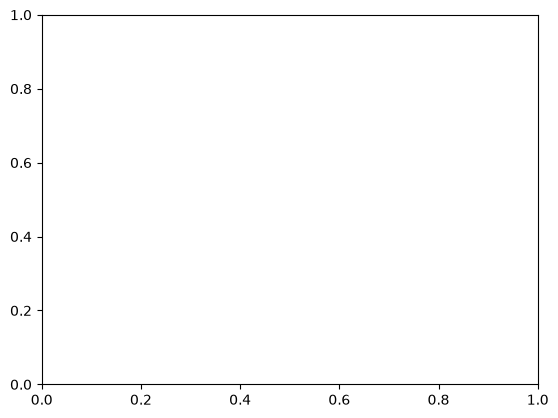

In [22]:
try:
    fig, ax = plot_shapes(shape_file_name)
except Exception as e:
    print(f"Error: {e}")

Here is an example of how to create a new shapefile with a DOTNAME field. Often you might want to combine metadata, for example if you had a shapefile of US counties you could create a "STATE:COUNTY" DOTNAME. In this example we only have one field so we'll just use that.

In [30]:
def add_dotname(shape_file_name):
    new_shape_file_name = shape_file_name + "_DN"

    # shapefiles
    sf = Reader(shape_file_name)
    sw = Writer(new_shape_file_name)

    print(sf.fields)
    
    # add the original fields
    for i, field in enumerate(sf.fields):
        if i > 0:
            sw.field(*field)
    # add the new field
    sw.field("DOTNAME", "C")

    for i, shaperec in enumerate(sf.iterShapeRecords()):
        # add the new field
        sw.record(*shaperec.record, "HABITATS:HOTSPOTS")
        # add the shape
        sw.shape(shaperec.shape)

    sw.close()
    sf.close()

    return new_shape_file_name


new_shape_file_name = add_dotname(shape_file_name)
print(new_shape_file_name)
print()

[Field(name="DeletionFlag", field_type=FieldType.C, size=1, decimal=0), Field(name="lyr_1", field_type=FieldType.N, size=9, decimal=0)]
./data/FairSeas_pelagic_habitats_hotspots_80_new_DN



and now we can plot:

[Field(name="DeletionFlag", field_type=FieldType.C, size=1, decimal=0), Field(name="lyr_1", field_type=FieldType.N, size=9, decimal=0), Field(name="DOTNAME", field_type=FieldType.C, size=50, decimal=0)]


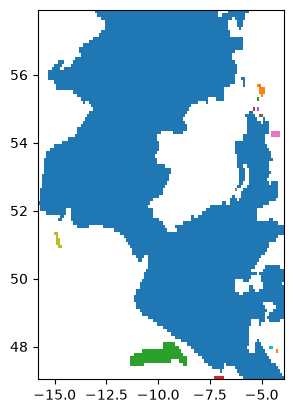

In [31]:
fig, ax = plot_shapes(new_shape_file_name)
ax.set_aspect(long_mult(0.5 * (sf.bbox[1] + sf.bbox[3])))